# FamInsureCo Medical Insurance Cost Analysis

## Project Overview
This project uses Python, pandas, and Matplotlib to explore factors associated with medical insurance charges. The analysis focuses on BMI, smoking status, region, sex, outliers, and feature correlations.

The goal is to identify patterns in insurance costs, evaluate how high-cost observations affect summary relationships, and communicate findings through reproducible analysis and visualizations.

## Business Questions

- How are BMI and medical insurance charges related?
- Does smoking status meaningfully change the relationship between BMI and insurance charges?
- How do insurance-charge distributions differ across smokers and non-smokers?
- Do region or sex show meaningful differences once smoking status is considered?
- How many high-cost outliers are present, and how much data remains after applying the IQR rule?
- Which variables are most strongly correlated with medical insurance charges?
- How do feature correlations change after high-cost outliers are removed?

## Tools & Techniques

- **Python**
- **pandas** for data loading, aggregation, filtering, and correlation analysis
- **Matplotlib** for scatter plots, histograms, box plots, and correlation visualizations
- Descriptive statistics
- Grouped aggregations
- IQR-based outlier detection
- Correlation analysis
- Comparative visualization

## 1. Setup and Data Loading

The project uses two public practice datasets: one for descriptive analysis and one containing encoded variables used for intermediate statistical analysis.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (8, 5)
warnings.filterwarnings('ignore')


In [2]:
data_source_1 = 'https://raw.github.com/chrishuisb1990/practice_datasets/main/FIC_Descriptive_Statistics_Data.csv'
data_source_2 = 'https://raw.github.com/chrishuisb1990/practice_datasets/main/FIC_Intermediate_Descriptive_Statistics_Data.csv'
descriptive_df = pd.read_csv(data_source_1)
intermediate_df = pd.read_csv(data_source_2)

descriptive_df.head()


,age,sex,bmi,bmi_classification,smoker,region,medical_insurance_charges,bmi.1
0,18,male,23.21,Healthy,no,southeast,1121.8739,23.21
1,19,male,19.80,Healthy,no,southwest,1241.5650,19.80
2,19,male,20.30,Healthy,no,southwest,1242.2600,20.30
3,19,male,20.70,Healthy,no,southwest,1242.8160,20.70
4,21,male,23.21,Healthy,no,southeast,1515.3449,23.21


## 2. BMI and Medical Insurance Charges

The first step is to examine the relationship between BMI and medical insurance charges at the individual level.

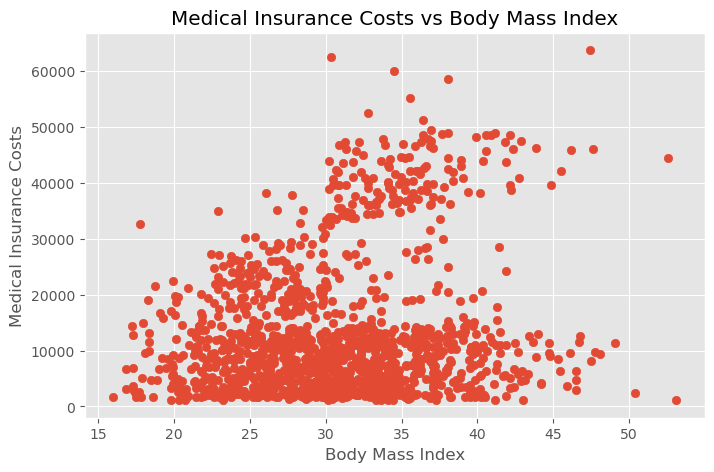

In [3]:
plt.scatter(
    descriptive_df['bmi'],
    descriptive_df['medical_insurance_charges']
)

plt.xlabel('Body Mass Index')
plt.ylabel('Medical Insurance Costs')
plt.title('Medical Insurance Costs vs Body Mass Index')

plt.show()

The scatter plot shows substantial variation in insurance charges across BMI values. BMI alone does not fully explain the spread in costs, which motivates looking at additional variables and grouped patterns.

### BMI Classification Summary

Insurance charges are aggregated by BMI classification to compare the number of individuals in each group along with mean, total, and standard deviation of charges.

In [4]:
aggregated_df = descriptive_df.groupby('bmi_classification').agg(
    Total_Number_Individuals=('bmi_classification', 'count'),
    Mean_Medical_Insurance_Charges=('medical_insurance_charges', 'mean'),
    Sum_Medical_Insurance_Charges=('medical_insurance_charges', 'sum'),
    Std_Medical_Insurance_Charges=('medical_insurance_charges', 'std')
)

aggregated_df

,Total_Number_Individuals,Mean_Medical_Insurance_Charges,Sum_Medical_Insurance_Charges,Std_Medical_Insurance_Charges
bmi_classification,,,,
Healthy,221,10404.900084,2.299483e+06,7508.165722
Overweight,716,15491.542238,1.109194e+07,14508.128111
Slightly Overweight,380,11006.809989,4.182588e+06,8004.176052
Underweight,21,8657.620652,1.818100e+05,7591.730101


The overweight group is the largest group in the dataset and also has the highest mean medical insurance charges among the BMI classifications shown. However, group size and charge variability make it important not to interpret BMI category alone as the primary driver of insurance cost.

### Aggregated BMI Classification Patterns

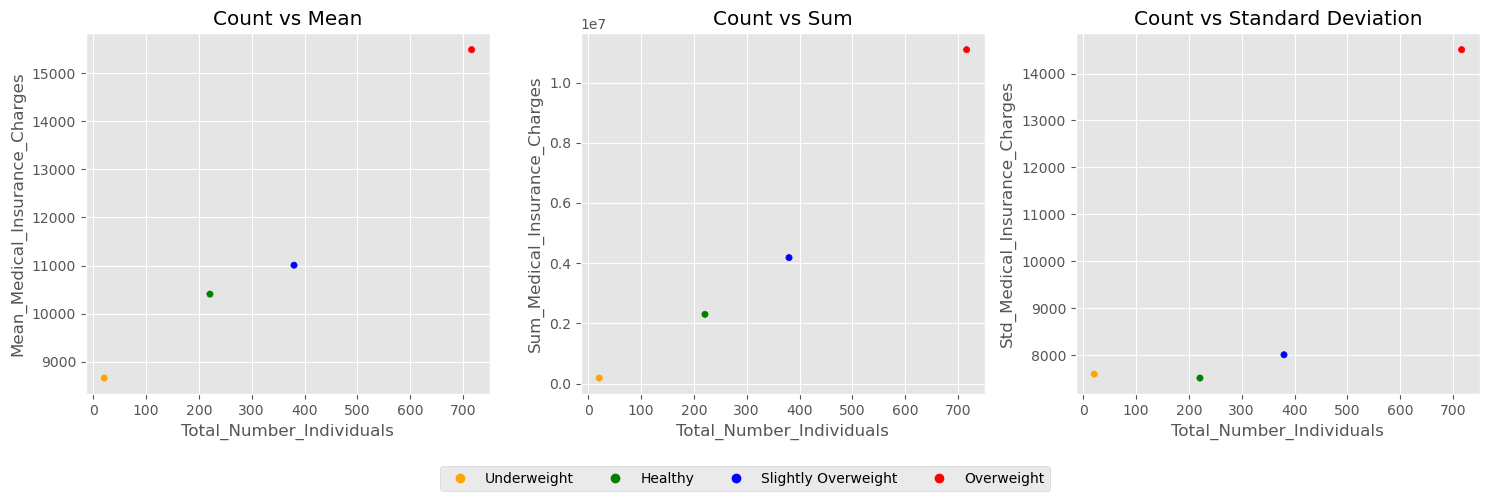

In [5]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {
    'Underweight': 'orange',
    'Healthy': 'green',
    'Slightly Overweight': 'blue',
    'Overweight': 'red'
}

point_colors = aggregated_df.index.map(colors)

aggregated_df.plot(
    kind='scatter',
    x='Total_Number_Individuals',
    y='Mean_Medical_Insurance_Charges',
    c=point_colors,
    ax=axes[0]
)
axes[0].set_title('Count vs Mean')

aggregated_df.plot(
    kind='scatter',
    x='Total_Number_Individuals',
    y='Sum_Medical_Insurance_Charges',
    c=point_colors,
    ax=axes[1]
)
axes[1].set_title('Count vs Sum')

aggregated_df.plot(
    kind='scatter',
    x='Total_Number_Individuals',
    y='Std_Medical_Insurance_Charges',
    c=point_colors,
    ax=axes[2]
)
axes[2].set_title('Count vs Standard Deviation')

handles = []

for label, color in colors.items():
    handles.append(
        Line2D(
            [0],
            [0],
            marker='o',
            color=color,
            label=label,
            linestyle='None'
        )
    )

fig.legend(
    handles=handles,
    loc='lower center',
    ncol=4
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

### Individual-Level BMI Patterns

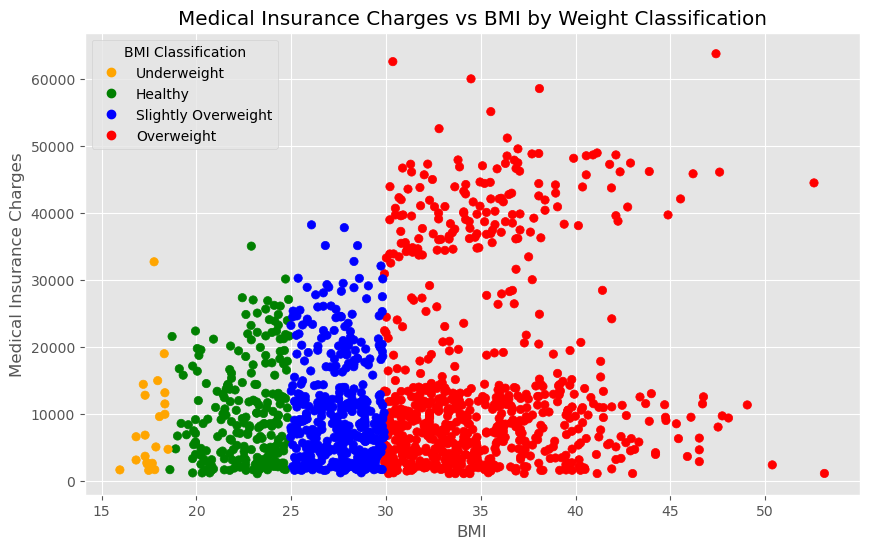

In [6]:
from matplotlib.lines import Line2D

point_colors = descriptive_df['bmi_classification'].map(colors)

plt.figure(figsize=(10, 6))

plt.scatter(
    descriptive_df['bmi'],
    descriptive_df['medical_insurance_charges'],
    c=point_colors
)

plt.xlabel('BMI')
plt.ylabel('Medical Insurance Charges')
plt.title('Medical Insurance Charges vs BMI by Weight Classification')

handles = []

for label, color in colors.items():
    handles.append(
        Line2D(
            [0],
            [0],
            marker='o',
            color=color,
            label=label,
            linestyle='None'
        )
    )

plt.legend(handles=handles, title='BMI Classification')

plt.show()

## 3. Smoking Status and Insurance Charges

Smoking status is introduced as an additional segmentation variable to test whether it helps explain the wide variation in medical insurance charges.

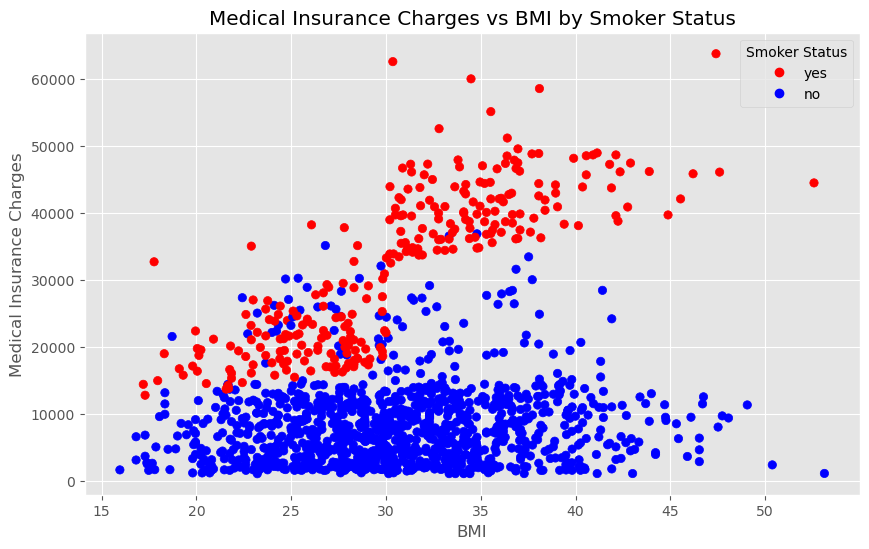

In [7]:
smoker_colors = {
    'yes': 'red',
    'no': 'blue'
}

smoker_point_colors = descriptive_df['smoker'].map(smoker_colors)

plt.figure(figsize=(10, 6))

plt.scatter(
    descriptive_df['bmi'],
    descriptive_df['medical_insurance_charges'],
    c=smoker_point_colors
)

plt.xlabel('BMI')
plt.ylabel('Medical Insurance Charges')
plt.title('Medical Insurance Charges vs BMI by Smoker Status')

handles = []

for label, color in smoker_colors.items():
    handles.append(
        Line2D(
            [0],
            [0],
            marker='o',
            color=color,
            label=label,
            linestyle='None'
        )
    )

plt.legend(handles=handles, title='Smoker Status')

plt.show()

The smoker segmentation reveals a much clearer separation in insurance charges than BMI alone. Higher-charge observations are heavily concentrated among smokers, suggesting smoking status is an important factor to examine throughout the rest of the analysis.

### Charge Distributions for Smokers and Non-Smokers

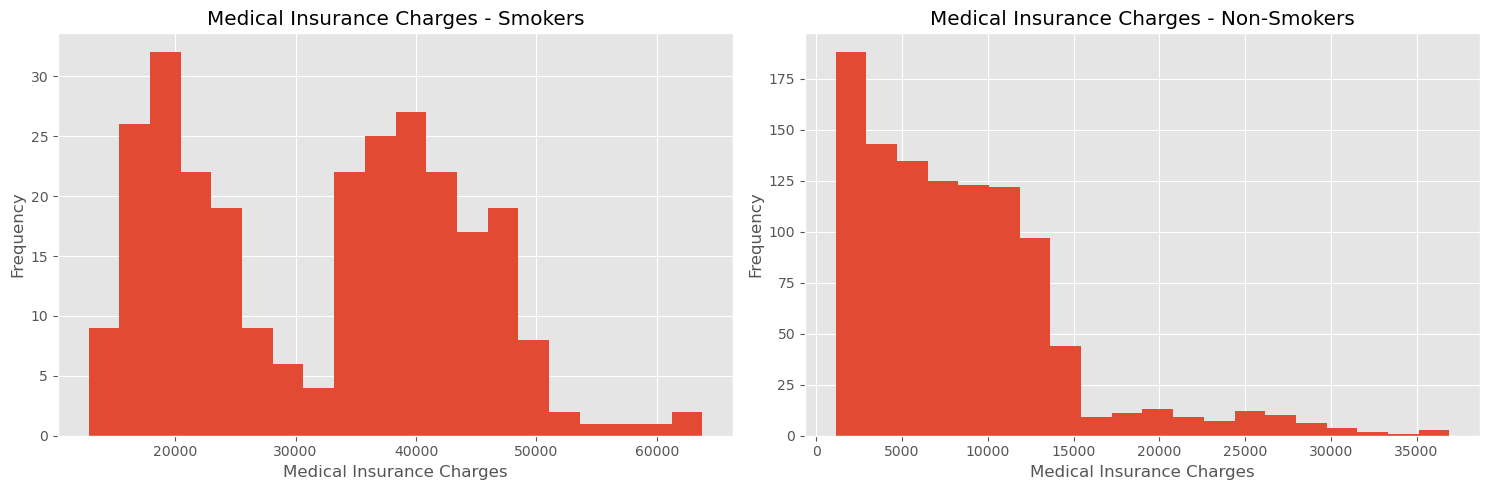

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

smokers = descriptive_df[descriptive_df['smoker'] == 'yes']
non_smokers = descriptive_df[descriptive_df['smoker'] == 'no']

axes[0].hist(smokers['medical_insurance_charges'], bins=20)
axes[0].set_title('Medical Insurance Charges - Smokers')
axes[0].set_xlabel('Medical Insurance Charges')
axes[0].set_ylabel('Frequency')

axes[1].hist(non_smokers['medical_insurance_charges'], bins=20)
axes[1].set_title('Medical Insurance Charges - Non-Smokers')
axes[1].set_xlabel('Medical Insurance Charges')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

The distributions reinforce the separation visible in the scatter plot. Smokers show substantially more high-cost observations, while non-smokers are concentrated at lower insurance-charge levels.

## 4. Regional and Sex-Based Comparisons

Box plots are used to compare charge distributions within smoker and non-smoker groups across region and sex.

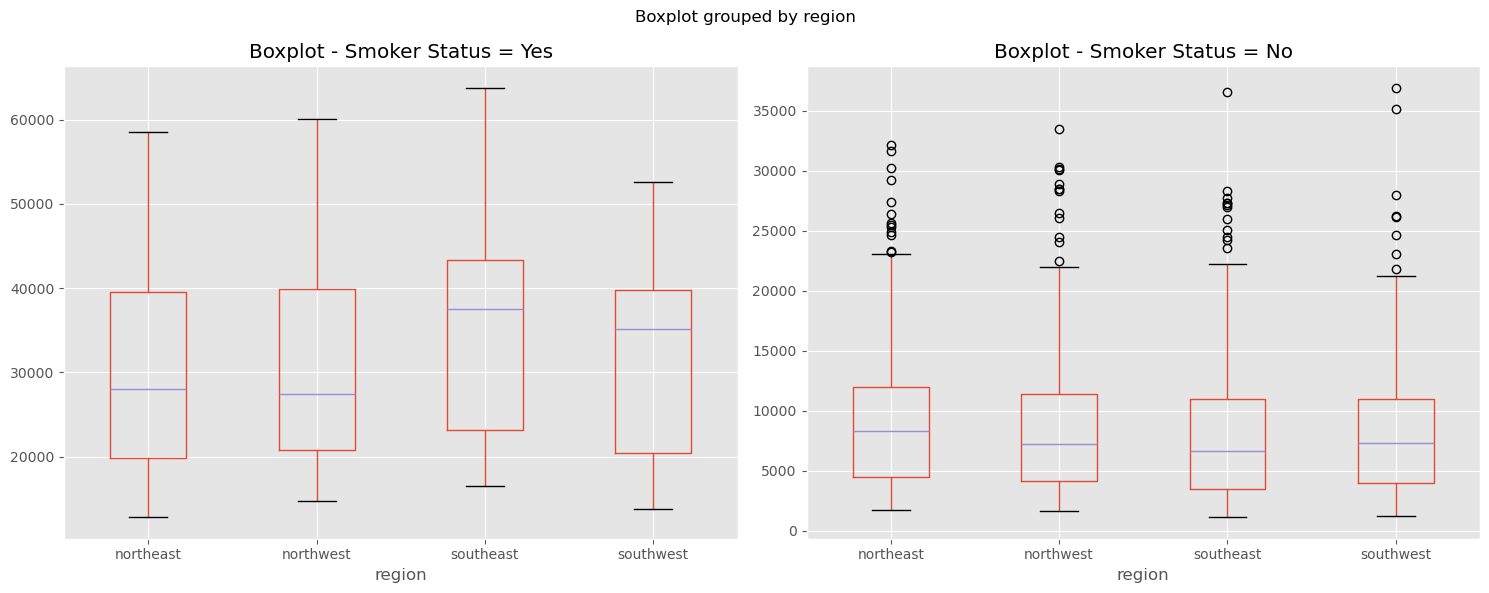

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

smokers = descriptive_df[descriptive_df['smoker'] == 'yes']
non_smokers = descriptive_df[descriptive_df['smoker'] == 'no']

smokers.boxplot(
    column='medical_insurance_charges',
    by='region',
    ax=axes[0]
)
axes[0].set_title('Boxplot - Smoker Status = Yes')
axes[0].set_xlabel('region')

non_smokers.boxplot(
    column='medical_insurance_charges',
    by='region',
    ax=axes[1]
)
axes[1].set_title('Boxplot - Smoker Status = No')
axes[1].set_xlabel('region')

fig.suptitle('Boxplot grouped by region')

plt.tight_layout()
plt.show()

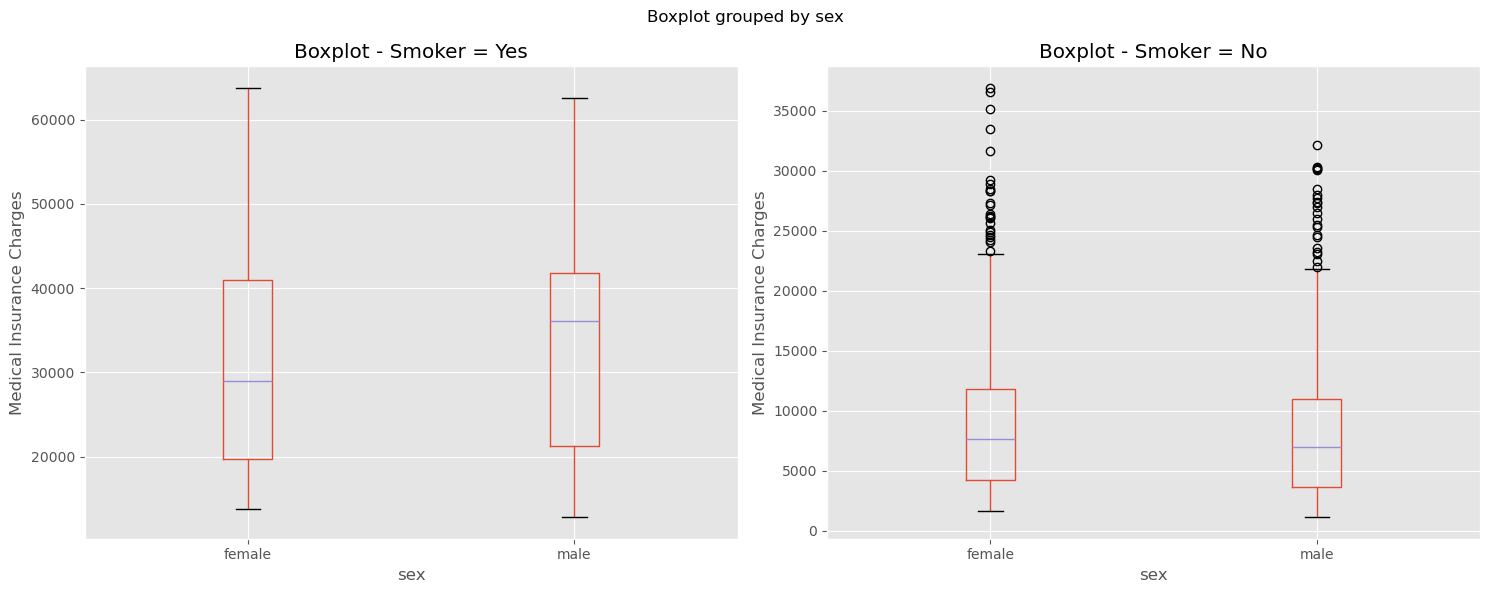

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

smokers = descriptive_df[descriptive_df['smoker'] == 'yes']
non_smokers = descriptive_df[descriptive_df['smoker'] == 'no']

smokers.boxplot(
    column='medical_insurance_charges',
    by='sex',
    ax=axes[0]
)
axes[0].set_title('Boxplot - Smoker = Yes')
axes[0].set_xlabel('sex')
axes[0].set_ylabel('Medical Insurance Charges')

non_smokers.boxplot(
    column='medical_insurance_charges',
    by='sex',
    ax=axes[1]
)
axes[1].set_title('Boxplot - Smoker = No')
axes[1].set_xlabel('sex')
axes[1].set_ylabel('Medical Insurance Charges')

fig.suptitle('Boxplot grouped by sex')

plt.tight_layout()
plt.show()

Across these comparisons, smoking status remains a more prominent separator of medical insurance charges than either region or sex. The box plots also show the presence of high-cost observations that warrant a closer outlier analysis.

## 5. Outlier Analysis

The interquartile range (IQR) method is used to identify unusually high medical insurance charges. Observations above `Q3 + 1.5 × IQR` are treated as high-cost outliers for this analysis.

In [11]:
Q1 = intermediate_df['medical_insurance_charges'].quantile(0.25)
Q3 = intermediate_df['medical_insurance_charges'].quantile(0.75)

IQR = Q3 - Q1

print(IQR)

11899.625365


In [12]:
Lower_Limit = Q1 - 1.5 * IQR
Upper_Limit = Q3 + 1.5 * IQR

intermediate_df_outliers = intermediate_df[
    intermediate_df['medical_insurance_charges'] > Upper_Limit
]

print("Lower Limit:", Lower_Limit)
print("Upper Limit:", Upper_Limit)
print("Number of Outliers:", len(intermediate_df_outliers))

intermediate_df_no_outliers = intermediate_df[
    intermediate_df['medical_insurance_charges'] <= Upper_Limit
]

percentage_remaining = (
    len(intermediate_df_no_outliers) / len(intermediate_df)
) * 100

print("Percentage of Data Remaining:", percentage_remaining)

intermediate_df_outliers

Lower Limit: -13109.1508975
Upper Limit: 34489.350562499996
Number of Outliers: 139
Percentage of Data Remaining: 89.61136023916293


,age,bmi,BMI_Healthy,BMI_Overweight,BMI_Slightly_Overweight,BMI_Underweight,Biological Marker,Smoker,southeast,southwest,northwest,northeast,Young Adult,Adult,Mature Age Adult,Senior,medical_insurance_charges
214,45,22.895,1,0,0,0,1,1,0,0,0,1,0,0,1,0,35069.37452
480,59,34.800,0,1,0,0,0,0,0,1,0,0,0,0,1,0,36910.60803
489,61,33.330,0,1,0,0,0,0,1,0,0,0,0,0,0,1,36580.28216
511,34,31.920,0,1,0,0,0,1,0,0,0,1,0,1,0,0,37701.87680
512,37,34.800,0,1,0,0,0,1,0,1,0,0,0,0,1,0,39836.51900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
937,62,30.875,0,1,0,0,1,1,0,0,1,0,0,0,0,1,46718.16325
1070,55,26.800,0,0,1,0,0,0,0,1,0,0,0,0,1,0,35160.13457
1290,24,28.500,0,0,1,0,1,1,0,0,0,1,1,0,0,0,35147.52848
1293,42,26.070,0,0,1,0,1,1,1,0,0,0,0,0,1,0,38245.59327


### Outlier Interpretation

Using the IQR rule:

- **IQR:** approximately 11,899.63
- **Upper limit:** approximately 34,489.35
- **High-cost outliers identified:** 139
- **Data remaining after removing those observations:** approximately 89.6%

Removing these observations leaves most of the dataset available for comparison, but the high-cost cases may still represent legitimate insurance experiences rather than data errors. For that reason, the analysis compares results both with and without them instead of assuming they should always be discarded.

## 6. Feature Correlation Analysis

The encoded dataset is used to compare numeric-feature correlations with medical insurance charges.

In [13]:
correlated_df = intermediate_df.corr(numeric_only=True)

correlated_df['medical_insurance_charges'] \
    .drop('medical_insurance_charges') \
    .sort_values(ascending=False)

Smoker                     0.787251
age                        0.299008
Senior                     0.201118
bmi                        0.198341
BMI_Overweight             0.196857
Mature Age Adult           0.137666
southeast                  0.073982
Biological Marker          0.057292
northeast                  0.006349
northwest                 -0.039905
southwest                 -0.043210
BMI_Underweight           -0.044960
BMI_Healthy               -0.106512
Adult                     -0.114735
BMI_Slightly_Overweight   -0.117768
Young Adult               -0.188178
Name: medical_insurance_charges, dtype: float64

Smoking status has the strongest positive correlation with medical insurance charges at approximately **0.79**. Age has a weaker positive correlation of approximately **0.30**, while BMI is approximately **0.20**. These results reinforce the earlier visual pattern that smoking status has the strongest observed relationship with charges among the features analyzed.

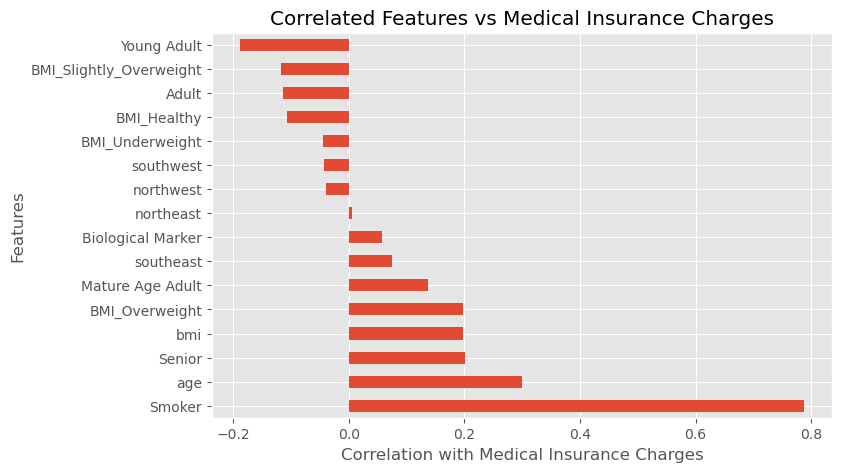

In [14]:
correlation_values = (
    correlated_df['medical_insurance_charges']
    .drop('medical_insurance_charges')
    .sort_values(ascending=False)
)

correlation_values.plot(kind='barh')

plt.xlabel('Correlation with Medical Insurance Charges')
plt.ylabel('Features')
plt.title('Correlated Features vs Medical Insurance Charges')

plt.show()

## 7. Correlation Sensitivity to Outlier Removal

To understand whether high-cost observations materially affect the relationships in the data, feature correlations are compared before and after removing the IQR-defined high-cost outliers.

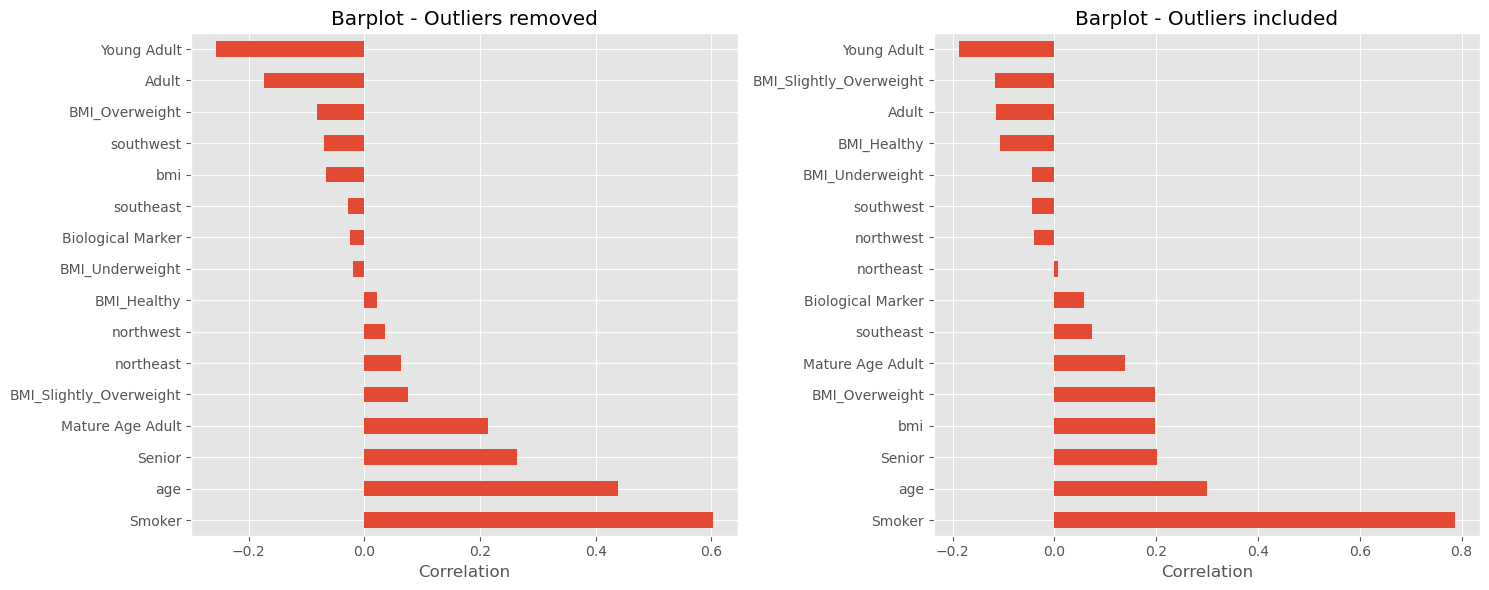

In [15]:
# Remove the outliers using the Upper_Limit from Step 13
intermediate_df_without_outliers = intermediate_df[
    ~(intermediate_df['medical_insurance_charges'] > Upper_Limit)
]

# Correlations with outliers removed
corr_without_outliers = (
    intermediate_df_without_outliers
    .corr(numeric_only=True)['medical_insurance_charges']
    .drop('medical_insurance_charges')
    .sort_values(ascending=False)
)

# Correlations with outliers included
corr_with_outliers = (
    intermediate_df
    .corr(numeric_only=True)['medical_insurance_charges']
    .drop('medical_insurance_charges')
    .sort_values(ascending=False)
)

# Create two horizontal bar plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

corr_without_outliers.plot(
    kind='barh',
    ax=axes[0]
)
axes[0].set_title('Barplot - Outliers removed')
axes[0].set_xlabel('Correlation')

corr_with_outliers.plot(
    kind='barh',
    ax=axes[1]
)
axes[1].set_title('Barplot - Outliers included')
axes[1].set_xlabel('Correlation')

plt.tight_layout()
plt.show()

Smoking status remains the strongest positive correlate of medical insurance charges after high-cost outliers are removed, although the relationship becomes weaker. Age and Senior status become relatively more prominent, while the relationship between BMI and charges weakens.

This comparison shows why outlier treatment should be evaluated carefully: removing extreme observations can change the apparent strength of relationships even when the overall ranking of the most important feature remains similar.

## Key Findings

- BMI by itself shows considerable variation in medical insurance charges and does not fully explain cost differences.
- Smoking status provides the clearest separation in insurance charges across the visual analyses.
- Smoker status has the strongest positive correlation with medical insurance charges in the encoded dataset, at approximately **0.79**.
- The IQR method identifies **139 high-cost observations**, leaving approximately **89.6%** of the dataset after removal.
- Correlations change after outlier removal, demonstrating that extreme values can materially influence statistical relationships.
- Region and sex show some distributional differences, but smoking status remains the more prominent pattern in this analysis.

## Limitations

This is an exploratory analysis of the available dataset and identifies associations rather than causal relationships. Correlation does not establish that a variable directly causes higher insurance charges. Additional modeling and domain context would be needed to estimate causal or predictive effects.

## Portfolio Note

This analysis was completed as part of data analytics coursework and adapted into a portfolio-ready notebook to highlight Python, pandas, visualization, outlier analysis, and statistical interpretation skills.